# 04 · Part C — Uplift Modeling

Parts A and B answered "what is the average effect?"; here we ask "for **whom** is it largest?" We estimate the per-customer effect (CATE), rank customers by it, split them into the four segments, and validate any "sleeping dog" tail on held-out data before believing it. We model on the original randomized data — unbiased individual effects need the experiment — with conversion as the outcome.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklift.metrics import uplift_curve

%matplotlib inline
warnings.filterwarnings("ignore")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_prep as dp
from src import uplift as up

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

OUTCOME = "conversion"
df = dp.add_treatment_flag(dp.load_raw())
train_df, test_df = up.split_train_test(df, seed=42, test_size=0.3)
_, yte, tte = up._xyt(test_df, OUTCOME)
print(f"train {len(train_df):,}  |  test {len(test_df):,}  (all evaluation is on the held-out test set)")

train 44,800  |  test 19,200  (all evaluation is on the held-out test set)


## 1. Two uplift learners

- **T-learner (Two Models):** separate outcome models for treated and control; uplift = p₁(x) − p₀(x).
- **S-learner (Solo Model):** one model with treatment as a feature; uplift = pred(T=1) − pred(T=0).

Base learner is logistic regression.

In [2]:
t_model = up.fit_t_learner(train_df, OUTCOME)
s_model = up.fit_s_learner(train_df, OUTCOME)
u_t = up.predict_uplift(t_model, test_df, OUTCOME)
u_s = up.predict_uplift(s_model, test_df, OUTCOME)

print("T-learner:", {k: round(v, 4) for k, v in up.evaluate(test_df, u_t, OUTCOME).items()})
print("S-learner:", {k: round(v, 4) for k, v in up.evaluate(test_df, u_s, OUTCOME).items()})

T-learner: {'qini_auc': 0.0429, 'uplift_auc': 0.0021}
S-learner: {'qini_auc': 0.0107, 'uplift_auc': 0.0005}


## 2. Evaluate with uplift metrics

Accuracy is meaningless for uplift (an individual's true uplift is never observed). We use the Qini / uplift curve — sort by predicted uplift and plot cumulative incremental conversions; the area above the random diagonal is the Qini / AUUC score. The T-learner out-ranks the S-learner, so we carry it forward.

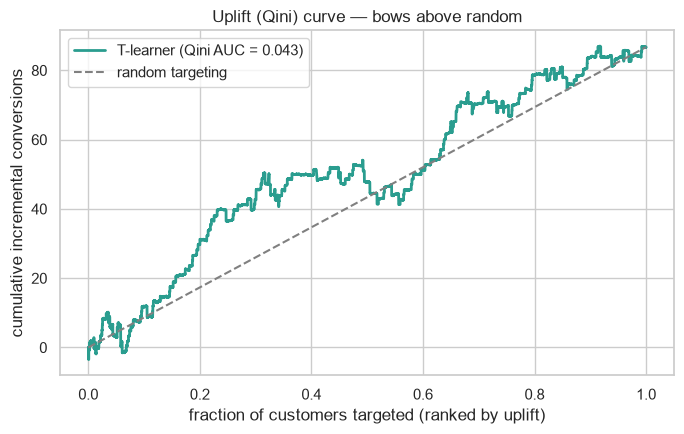

In [3]:
x_uc, y_uc = uplift_curve(yte, u_t, tte)
frac = x_uc / x_uc[-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(frac, y_uc, color="#2a9d8f", lw=2, label=f"T-learner (Qini AUC = {up.evaluate(test_df, u_t, OUTCOME)['qini_auc']:.3f})")
ax.plot([0, 1], [y_uc[0], y_uc[-1]], ls="--", color="grey", label="random targeting")
ax.set_xlabel("fraction of customers targeted (ranked by uplift)")
ax.set_ylabel("cumulative incremental conversions")
ax.set_title("Uplift (Qini) curve — bows above random"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "04_qini_curve.png", dpi=120, bbox_inches="tight"); plt.show()

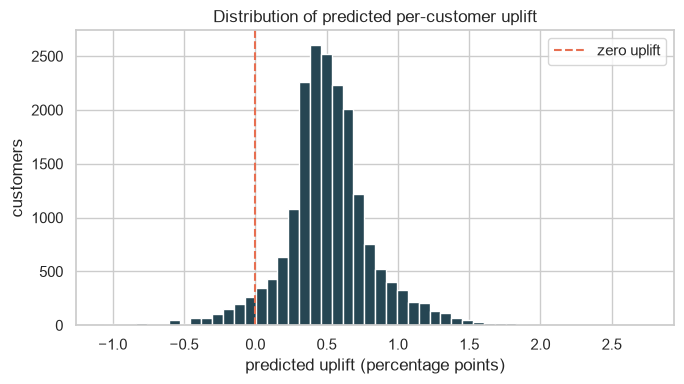

predicted uplift range: [-1.06, +2.75] pp; 5% predicted negative (candidate sleeping dogs)


In [4]:
p0, p1 = up.t_learner_p0_p1(t_model, test_df, OUTCOME)
uplift = p1 - p0
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(uplift * 100, bins=50, color="#264653")
ax.axvline(0, color="#e76f51", ls="--", label="zero uplift")
ax.set_xlabel("predicted uplift (percentage points)"); ax.set_ylabel("customers")
ax.set_title("Distribution of predicted per-customer uplift"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "04_uplift_distribution.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"predicted uplift range: [{uplift.min()*100:+.2f}, {uplift.max()*100:+.2f}] pp; "
      f"{np.mean(uplift < 0):.0%} predicted negative (candidate sleeping dogs)")

## 3. Uplift vs a response model

A response model targets customers most likely to convert (rank by p₁), but many are sure things who'd buy anyway. An uplift model targets persuadables instead. We compare the incremental conversions each strategy captures as the target list grows.

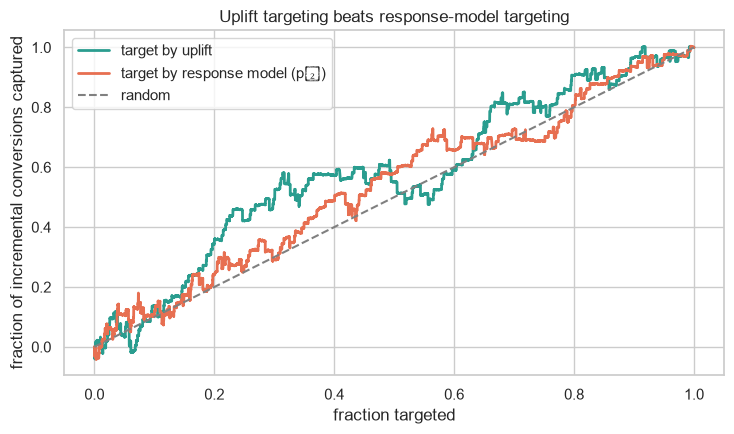

share of incremental conversions captured:
  top 20%:  uplift 26%   vs   response 23%   vs   random 20%
  top 30%:  uplift 47%   vs   response 32%   vs   random 30%
  top 40%:  uplift 58%   vs   response 44%   vs   random 40%


In [5]:
x_u, y_u = uplift_curve(yte, u_t, tte)          # rank by uplift
x_r, y_r = uplift_curve(yte, p1, tte)            # rank by response model (p1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x_u / x_u[-1], y_u / y_u[-1], color="#2a9d8f", lw=2, label="target by uplift")
ax.plot(x_r / x_r[-1], y_r / y_r[-1], color="#e76f51", lw=2, label="target by response model (p₁)")
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="random")
ax.set_xlabel("fraction targeted"); ax.set_ylabel("fraction of incremental conversions captured")
ax.set_title("Uplift targeting beats response-model targeting"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "04_capture_uplift_vs_response.png", dpi=120, bbox_inches="tight"); plt.show()

cap_u = up.capture_fractions(test_df, u_t, OUTCOME)
cap_r = up.capture_fractions(test_df, p1, OUTCOME)
print("share of incremental conversions captured:")
for f in [0.2, 0.3, 0.4]:
    print(f"  top {f:.0%}:  uplift {cap_u[f]:.0%}   vs   response {cap_r[f]:.0%}   vs   random {f:.0%}")

At the top 30–40%, uplift targeting captures more incremental conversions than a response model at the same cost — it skips the sure-things and finds the persuadables.

## 4. The four segments

Split customers into the classic quadrants using the T-learner's p₀ and p₁.

In [6]:
seg = up.segment_customers(p0, p1)
seg_df = pd.DataFrame({"segment": seg, "p0": p0, "p1": p1, "uplift": p1 - p0})
summary = (seg_df.groupby("segment")
           .agg(n=("uplift", "size"), mean_p0=("p0", "mean"),
                mean_p1=("p1", "mean"), mean_uplift=("uplift", "mean"))
           .assign(mean_p0=lambda d: (d.mean_p0*100).round(2),
                   mean_p1=lambda d: (d.mean_p1*100).round(2),
                   mean_uplift=lambda d: (d.mean_uplift*100).round(3)))
summary

,n,mean_p0,mean_p1,mean_uplift
segment,,,,
lost_cause,4576,0.24,0.64,0.402
persuadable,9133,0.48,1.23,0.750
sleeping_dog,934,1.49,1.28,-0.207
sure_thing,4557,0.82,1.12,0.304


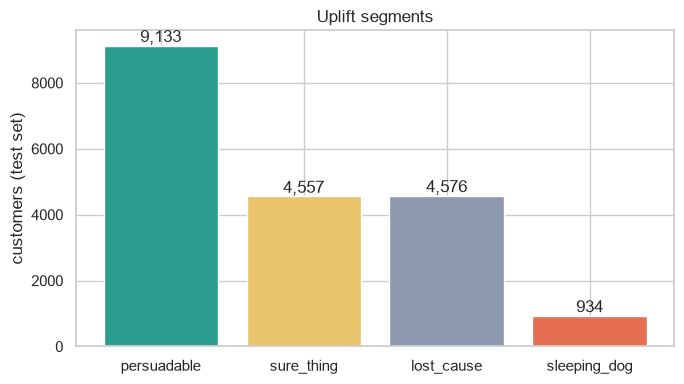

In [7]:
order = ["persuadable", "sure_thing", "lost_cause", "sleeping_dog"]
counts = seg_df.segment.value_counts().reindex(order)
colors = {"persuadable": "#2a9d8f", "sure_thing": "#e9c46a", "lost_cause": "#8d99ae", "sleeping_dog": "#e76f51"}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(order, counts.values, color=[colors[s] for s in order])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("customers (test set)"); ax.set_title("Uplift segments")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_segments.png", dpi=120, bbox_inches="tight"); plt.show()

**Persuadables** are where the value is. **Sure-things** buy anyway, **lost-causes** never buy, and the **sleeping-dog** quadrant is only a candidate until validated next.

### Scoring one customer at a time

The same fitted model also answers a per-record question: *should we email **this** customer?* Feed one row's raw features through `predict_customer`, then label it with `segment_for` using the population thresholds above. This is what powers the dashboard's **"Score an individual customer"** tool — an aggregate targeting policy turned into a single-customer decision, like a credit-risk scorer.

In [8]:
# Score two hypothetical customers with the SAME fitted T-learner (no retraining) —
# this is exactly what the dashboard's "Score an individual customer" tool does: encode one
# raw row, realign its one-hot columns to the training matrix, read p0/p1, then label it with
# the population segment thresholds.
feature_columns = list(dp.encode_features(train_df).columns)
tau, p0_median = up.segment_thresholds(p0, p1)

examples = {
    "loyal · multichannel":   dict(recency=1, history=50.0, mens=0, womens=0, newbie=0,
                                   history_segment="1) $0 - $100", zip_code="Surburban",
                                   channel="Multichannel"),
    "lapsed · urban · phone": dict(recency=1, history=50.0, mens=0, womens=0, newbie=0,
                                   history_segment="1) $0 - $100", zip_code="Urban",
                                   channel="Phone"),
}
for name, cust in examples.items():
    c_p0, c_p1, c_u = up.predict_customer(t_model, cust, feature_columns)
    seg_one = up.segment_for(c_p0, c_p1, tau, p0_median)
    decision = "TARGET" if seg_one == "persuadable" else "skip"
    print(f"{name:24s}  p0={c_p0*100:5.2f}%  p1={c_p1*100:5.2f}%  "
          f"uplift={c_u*100:+.3f} pp  ->  {seg_one:12s} ({decision})")


loyal · multichannel      p0= 0.61%  p1= 1.16%  uplift=+0.547 pp  ->  persuadable  (TARGET)
lapsed · urban · phone    p0= 0.97%  p1= 0.87%  uplift=-0.100 pp  ->  sleeping_dog (skip)


## 5. Sleeping dogs — validate on a holdout

Per-customer uplift is noisy at ~0.9% conversion, so a negative prediction is not proof of harm. We take the customers flagged as negative-uplift and test their actual treated-vs-control conversion on the holdout, claiming a real effect only if the treated rate is significantly lower.

In [9]:
sd = up.sleeping_dog_holdout(test_df, u_t, OUTCOME)
print(f"flagged sleeping dogs: {sd['n_flagged']} customers (treated {sd['n_treated']}, control {sd['n_control']})")
print(f"actual conversion — treated {sd['treated_rate']:.4%}  vs  control {sd['control_rate']:.4%}")
print(f"lift = {sd['lift']*100:+.3f} pp   p = {sd['p_value']:.3f}")
print(f"\n=> Real sleeping dogs? {'YES' if sd['confirmed'] else 'NO — not statistically distinguishable from zero on holdout.'}")
print("   The model's negative predictions here are noise, not evidence of harm. We do NOT exclude these")
print("   customers on the model's say-so; we'd need a targeted follow-up experiment to confirm any harm.")

flagged sleeping dogs: 934 customers (treated 622, control 312)
actual conversion — treated 0.9646%  vs  control 0.6410%
lift = +0.324 pp   p = 0.613

=> Real sleeping dogs? NO — not statistically distinguishable from zero on holdout.
   The model's negative predictions here are noise, not evidence of harm. We do NOT exclude these
   customers on the model's say-so; we'd need a targeted follow-up experiment to confirm any harm.


The model flags a candidate sleeping-dog segment, but the holdout does not confirm it — so we don't claim it.

## 6. Targeting policy & ROI

Rank customers by predicted uplift and, at each reach level, compute realized profit: incremental spend (treated − control) at 30% margin minus the $0.10 send cost.

Spend is 99% zeros with a third of revenue from ~0.1% of customers, so each point is a difference of two subsample means of a skewed variable and a single curve zig-zags. We bootstrap the evaluation (resample the test set 300×, no model refit) and plot the median with a 5–95% band.

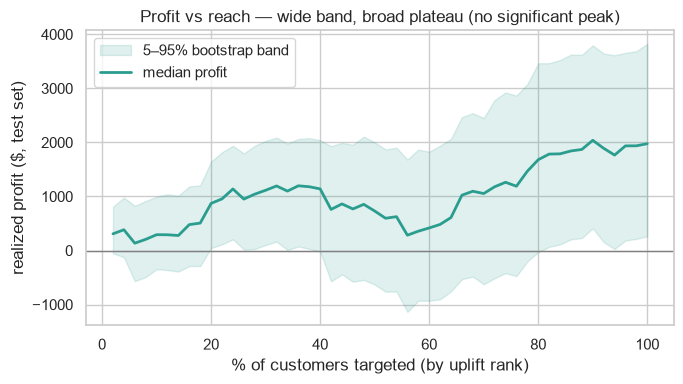

at 90% reach:  median $2,039   band [$411, $3,796]
at full reach: median $1,977   band [$262, $3,824]
band ~$3,562 wide at full reach; the top-90% 'peak' sits only ~3% above full reach
=> that gap is inside the noise: broad plateau, not a sharp optimum. Target broadly.


In [10]:
fr, profit, lo, hi = up.targeting_profit_curve(test_df, u_t, margin=0.30, cost=0.10, n_boot=300, seed=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(fr * 100, lo, hi, color="#2a9d8f", alpha=0.15, label="5–95% bootstrap band")
ax.plot(fr * 100, profit, color="#2a9d8f", lw=2, label="median profit")
ax.axhline(0, color="grey", lw=1)
ax.set_xlabel("% of customers targeted (by uplift rank)"); ax.set_ylabel("realized profit ($, test set)")
ax.set_title("Profit vs reach — wide band, broad plateau (no significant peak)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "04_targeting_profit.png", dpi=120, bbox_inches="tight"); plt.show()

at = lambda x, y: np.interp(x, fr, y)
print(f"at 90% reach:  median ${at(0.9, profit):,.0f}   band [${at(0.9, lo):,.0f}, ${at(0.9, hi):,.0f}]")
print(f"at full reach: median ${profit[-1]:,.0f}   band [${lo[-1]:,.0f}, ${hi[-1]:,.0f}]")
print(f"band ~${hi[-1] - lo[-1]:,.0f} wide at full reach; the top-90% 'peak' sits only ~3% above full reach")
print("=> that gap is inside the noise: broad plateau, not a sharp optimum. Target broadly.")

**Business read:** the bootstrap band is ~$3–4k wide and essentially flat over the top ~60–100%, and the apparent peak near 90% reach is only ~3% above full reach — inside the band. There is no trustworthy interior optimum: with these economics the offer is profitable for almost everyone, so the honest read is a broad plateau near full reach. The uplift model's value is therefore prioritization under a budget (capture more incremental conversions than a response model) and risk screening, not mass exclusion. A much higher send cost or lower margin would push the peak left and make uplift-based exclusion pay off.

## Part C takeaways from the above results

- Built two uplift learners; the T-learner ranks best (Qini AUC ≈ 0.043 vs 0.011).
- Uplift targeting beats a response model: at the top 30% it captures ~47% of incremental conversions vs ~32% (response) and 30% (random).
- Split customers into the four segments; the largest actionable group is persuadables.
- No confirmed sleeping dogs — the flagged tail did not reproduce as harm on the holdout.
- With the given economics the offer is broadly profitable, so uplift drives prioritization under a budget rather than mass exclusion.